<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:15px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#8B0000; overflow:hidden"><b> A complete deep learning NLP pipeline using LSTM for sentiment analysis </b></div>

## Key Takeaways

LSTM solves the vanishing gradient problem through its gating mechanisms
Sequential processing maintains context throughout the sentence
Embedding layer converts sparse tokens to dense semantic vectors
Proper preprocessing (tokenization, padding) is crucial
Regularization (dropout, early stopping) prevents overfitting
Evaluation should use multiple metrics, not just accuracy
Hyperparameter tuning significantly impacts performance

## The LSTM architecture remains a powerful and practical choice for text classification tasks, offering a good balance between performance and computational efficiency.

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#3168a1; overflow:hidden"><b> Libraries </b></div>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("LSTM TEXT CLASSIFICATION PROJECT")

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


LSTM TEXT CLASSIFICATION PROJECT
TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#3168a1; overflow:hidden"><b> Loading Dataset </b></div>

In [6]:
from tensorflow.keras.datasets import imdb

vocab_size = 10000
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=vocab_size)


word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

print(f"Training samples: {len(X_train_raw)}")
print(f"Test samples: {len(X_test_raw)}")
print(f"Vocabulary size: {vocab_size}")


def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

print(f"\nExample review (encoded): {X_train_raw[0][:20]}...")
print(f"Example review (decoded): {decode_review(X_train_raw[0])[:100]}...")
print(f"Sentiment: {'Positive' if y_train[0] == 1 else 'Negative'}")

Training samples: 25000
Test samples: 25000
Vocabulary size: 10000

Example review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]...
Example review (decoded): ? this film was just brilliant casting location scenery story direction everyone's really suited the...
Sentiment: Positive


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#3168a1; overflow:hidden"><b> Data preprocessing and embedding</b></div>

In [7]:
max_length = 200


X_train = pad_sequences(X_train_raw, maxlen=max_length, padding='post', truncating='post')
X_test = pad_sequences(X_test_raw, maxlen=max_length, padding='post', truncating='post')

print(f"Shape after padding:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nExample padded sequence shape: {X_train[0].shape}")
print(f"First 10 tokens: {X_train[0][:10]}")
print(f"Last 10 tokens (padded): {X_train[0][-10:]}")


X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nData split:")
print(f"Training set: {X_train_final.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")



Shape after padding:
X_train: (25000, 200)
X_test: (25000, 200)

Example padded sequence shape: (200,)
First 10 tokens: [   1   14   22   16   43  530  973 1622 1385   65]
Last 10 tokens (padded): [ 36  28 224  92  25 104   4 226  65  16]

Data split:
Training set: 20000 samples
Validation set: 5000 samples
Test set: 25000 samples


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#3168a1; overflow:hidden"><b>BUILD LSTM MODEL</b></div>

In [8]:

embedding_dim = 128
lstm_units = 64
dropout_rate = 0.5


model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length, name='embedding'),
    LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2, name='lstm'),
    Dropout(dropout_rate, name='dropout'),
    Dense(1, activation='sigmoid', name='output')
], name='LSTM_Classifier')


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

print("✓ Model built successfully!")
print("\nModel Architecture:")
print("=" * 80)
model.build(input_shape=(None, max_length))  # Build before summary
model.summary()
print("=" * 80)


total_params = model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")


emb_params = vocab_size * embedding_dim
lstm_params = 4 * (embedding_dim * lstm_units + lstm_units * lstm_units + lstm_units)
dense_params = lstm_units + 1

print(f"\nParameter Breakdown:")
print(f"  Embedding Layer: {emb_params:,}")
print(f"  LSTM Layer: {lstm_params:,}")
print(f"  Dense Layer: {dense_params:,}")

✓ Model built successfully!

Model Architecture:


Model: "LSTM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 1,329,473

Parameter Breakdown:
  Embedding Layer: 1,280,000
  LSTM Layer: 49,408
  Dense Layer: 65


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#3168a1; overflow:hidden"><b>BUILD LSTM MODEL</b></div>

In [9]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)


batch_size = 64
epochs = 10


print(f"\nTraining configuration:")
print(f"Batch size: {batch_size}")
print(f"Epochs: {epochs}")
print(f"Callbacks: Early Stopping, Reduce LR on Plateau")
print("\nTraining started...\n")

history = model.fit(
    X_train_final, y_train_final,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)




Training configuration:
Batch size: 64
Epochs: 10
Callbacks: Early Stopping, Reduce LR on Plateau

Training started...

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 182s 564ms/step - accuracy: 0.5208 - loss: 0.6924 - precision: 0.5209 - recall: 0.5337 - val_accuracy: 0.5486 - val_loss: 0.6794 - val_precision: 0.5279 - val_recall: 0.9204 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 176s 561ms/step - accuracy: 0.6192 - loss: 0.6444 - precision: 0.6034 - recall: 0.7157 - val_accuracy: 0.7640 - val_loss: 0.5406 - val_precision: 0.7435 - val_recall: 0.8060 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 176s 563ms/step - accuracy: 0.7204 - loss: 0.5607 - precision: 0.6977 - recall: 0.7857 - val_accuracy: 0.7884 - val_loss: 0.4995 - val_precision: 0.7948 - val_recall: 0.7776 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 175s 561ms/step - accuracy: 0.7892 - loss: 0.5030 - precision: 0.8155 - recall: 0.7494 - val_accuracy: 0.8082 - val_loss: 0.4

In [10]:
# Evaluate on test set
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    X_test, y_test, verbose=0
)

print(f"\nTest Set Performance:")
print(f"{'=' * 50}")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {2 * (test_precision * test_recall) / (test_precision + test_recall):.4f}")


y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()


print(f"\nClassification Report:")

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)




Test Set Performance:
Loss: 0.4927
Accuracy: 0.7951 (79.51%)
Precision: 0.7858
Recall: 0.8114
F1-Score: 0.7984

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.78      0.79     12500
    Positive       0.79      0.81      0.80     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000


Confusion Matrix:
[[ 9735  2765]
 [ 2358 10142]]


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#3168a1; overflow:hidden"><b>VISUALIZATIONS</b></div>

Visualization saved to: /home/claude/lstm_training_results.png


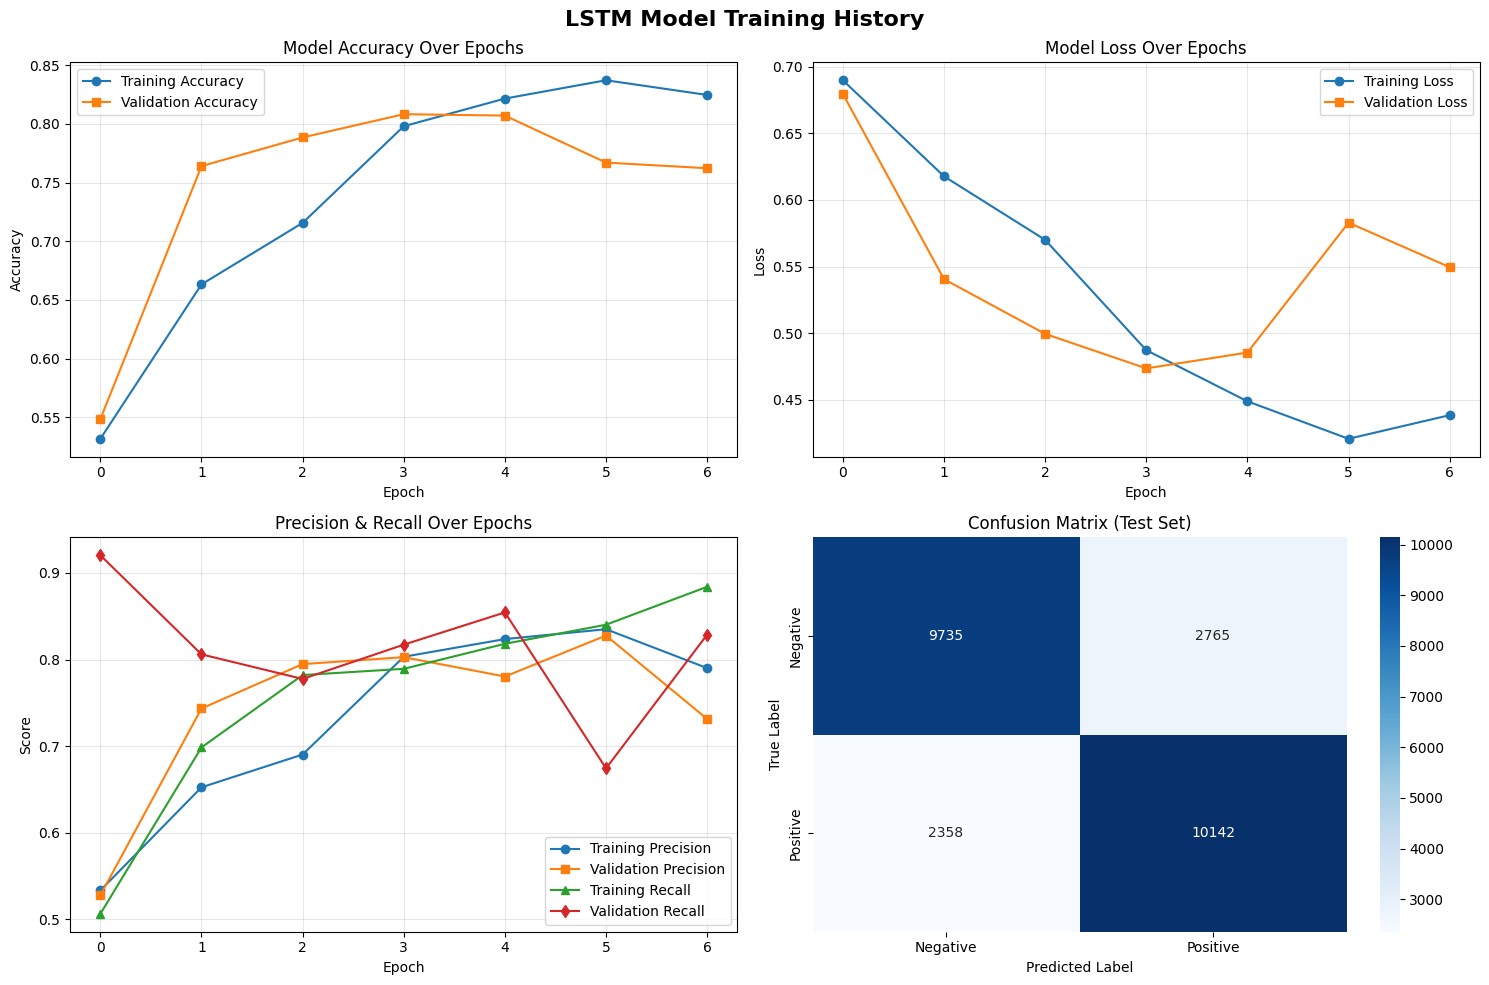

In [11]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('LSTM Model Training History', fontsize=16, fontweight='bold')


axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0, 0].set_title('Model Accuracy Over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)


axes[0, 1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[0, 1].set_title('Model Loss Over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)


axes[1, 0].plot(history.history['precision'], label='Training Precision', marker='o')
axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', marker='s')
axes[1, 0].plot(history.history['recall'], label='Training Recall', marker='^')
axes[1, 0].plot(history.history['val_recall'], label='Validation Recall', marker='d')
axes[1, 0].set_title('Precision & Recall Over Epochs')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1, 1].set_title('Confusion Matrix (Test Set)')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('lstm_training_results.png', dpi=300, bbox_inches='tight')
print(f"Visualization saved to: /home/claude/lstm_training_results.png")



<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#3168a1; overflow:hidden"><b>PREDICTIONs</b></div>

In [13]:
def predict_sentiment(text, show_confidence=True):

    print(f"\nText: '{text[:100]}...'")
    

sample_indices = [0, 100, 500, 1000, 5000]

print("\nSample Predictions:")

for idx in sample_indices:
    review = decode_review(X_test_raw[idx])
    prediction = model.predict(X_test[idx:idx+1], verbose=0)[0][0]
    true_label = y_test[idx]
    
    print(f"\nReview: {review[:80]}...")
    print(f"True Label: {'Positive' if true_label == 1 else 'Negative'}")
    print(f"Predicted: {'Positive' if prediction > 0.5 else 'Negative'} (confidence: {prediction:.4f})")
    print(f"{'✓ Correct' if (prediction > 0.5) == true_label else '✗ Incorrect'}")



Sample Predictions:

Review: ? please give this one a miss br br ? ? and the rest of the cast rendered terrib...
True Label: Negative
Predicted: Negative (confidence: 0.1564)
✓ Correct

Review: ? a quick glance at the premise of this film would seem to indicate just another...
True Label: Positive
Predicted: Negative (confidence: 0.1564)
✗ Incorrect

Review: ? this is a funny movie the bob eddie show feel of it could lead to a sequel but...
True Label: Positive
Predicted: Positive (confidence: 0.7719)
✓ Correct

Review: ? ? this is one of the worst movies i have ever seen the ? for the film is bette...
True Label: Negative
Predicted: Negative (confidence: 0.1564)
✓ Correct

Review: ? too bad they showed palm trees that could not be more inaccurate for ? in octo...
True Label: Positive
Predicted: Negative (confidence: 0.3528)
✗ Incorrect


In [14]:
model.save('lstm_text_classifier.keras')
print(f"Model saved to: lstm_text_classifier.keras")



Model saved to: lstm_text_classifier.keras
